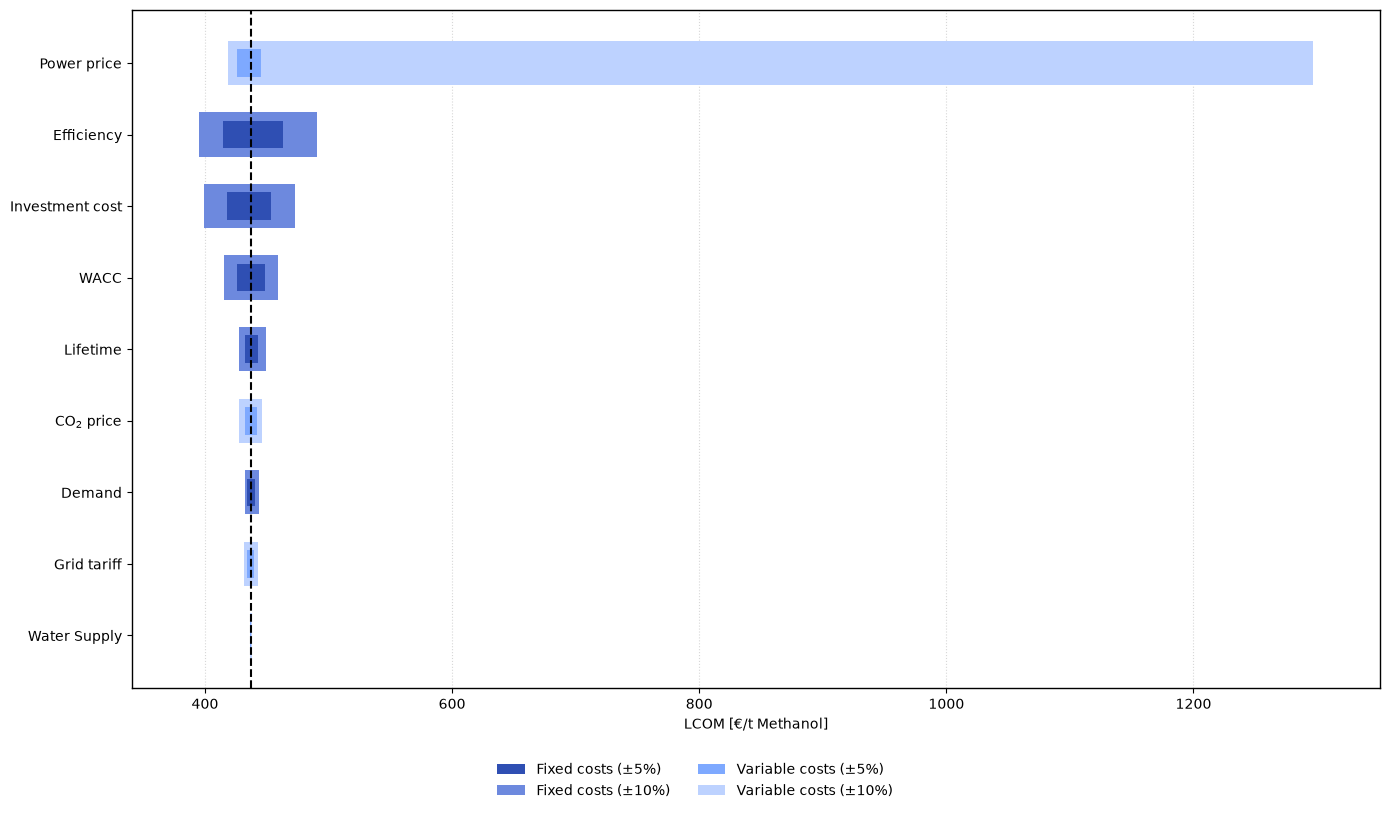

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# -----------------------
# Base value
# -----------------------
base = 437.09

# -----------------------
# Sensitivity data
# (value at -5%, value at +5%)
# -----------------------
sens_5 = {
    "Demand": (433.89, 440.66),
    "WACC": (426.11, 448.22),
    "Lifetime": (442.78, 432.10),
    "Investment cost": (417.56, 453.23),
    "CO$_2$ price": (432.41, 441.77),
    "Power price": (426.08, 445.00),
    "Efficiency": (462.83, 414.52),
    "Grid tariff": (434.29, 439.89),
    "Water Supply":(436.64, 437.54),
}

# -----------------------
# Sensitivity data
# (value at -10%, value at +10%)
# -----------------------
sens_10 = {
    "Demand": (432.12, 444.00),
    "WACC": (415.27, 459.48),
    "Lifetime": (449.27, 427.69),
    "Investment cost": (398.89, 472.59),
    "CO$_2$ price": (427.73, 446.45),
    "Power price": (418.38, 1296.82),
    "Efficiency": (490.92, 394.85),
    "Grid tariff": (431.50, 442.69),
    "Water Supply":(436.19, 437.99),
}

# -----------------------
# Cost type groups
# -----------------------
fixed_costs = {
    "WACC",
    "Lifetime",
    "Investment cost",
    "Demand",
    "Efficiency",
}

variable_costs = {
    "CO$_2$ price",
    "Power price",
    "Grid tariff",
}

# -----------------------
# Colors
# -----------------------
fixed_dark = "#2f4fb3"
fixed_light = "#6d89de"
variable_dark = "#7ea9ff"
variable_light = "#bdd2ff"
color_base = "black"

# -----------------------
# Common x-limits
# -----------------------
all_values = [base]
for d in (sens_5, sens_10):
    for minus, plus in d.values():
        all_values.extend([minus, plus])

x_min = min(all_values)
x_max = max(all_values)
pad = (x_max - x_min) * 0.06
common_xlim = (x_min - pad, x_max + pad)

# -----------------------
# Build ordering by largest span
# -----------------------
items = []
for param in sens_10.keys():
    minus5, plus5 = sens_5[param]
    minus10, plus10 = sens_10[param]

    left5, right5 = min(minus5, plus5), max(minus5, plus5)
    left10, right10 = min(minus10, plus10), max(minus10, plus10)

    span = max(right5 - left5, right10 - left10)
    family = "fixed" if param in fixed_costs else "variable"

    items.append((param, left5, right5, left10, right10, span, family))

items.sort(key=lambda x: x[5], reverse=True)

labels = [x[0] for x in items]
y = np.arange(len(labels))

# -----------------------
# Figure
# -----------------------
fig, ax = plt.subplots(figsize=(14, 8))

bar_h = 0.62

for idx, (_, left5, right5, left10, right10, _, family) in enumerate(items):
    if family == "fixed":
        light = fixed_light
        dark = fixed_dark
    else:
        light = variable_light
        dark = variable_dark

    # 10% range (outer, lighter)
    ax.barh(
        y[idx],
        right10 - left10,
        left=left10,
        height=bar_h,
        color=light,
        edgecolor="none",
        zorder=2
    )

    # 5% range (inner, darker)
    ax.barh(
        y[idx],
        right5 - left5,
        left=left5,
        height=bar_h * 0.62,
        color=dark,
        edgecolor="none",
        zorder=3
    )

# Base line
ax.axvline(base, color=color_base, linestyle="--", linewidth=1.5, zorder=4)

# Axes
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("LCOM [€/t Methanol]")
ax.set_xlim(common_xlim)
ax.grid(axis="x", linestyle=":", alpha=0.5)

# -----------------------
# Legend
# -----------------------
legend_handles = [
    Patch(facecolor=fixed_dark, edgecolor="none", label="Fixed costs (±5%)"),
    Patch(facecolor=fixed_light, edgecolor="none", label="Fixed costs (±10%)"),
    Patch(facecolor=variable_dark, edgecolor="none", label="Variable costs (±5%)"),
    Patch(facecolor=variable_light, edgecolor="none", label="Variable costs (±10%)"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

# -----------------------
# Spines
# -----------------------
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout(rect=[0, 0.06, 1, 1])

plt.savefig(
    "tornado_plot_methanol_updated.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

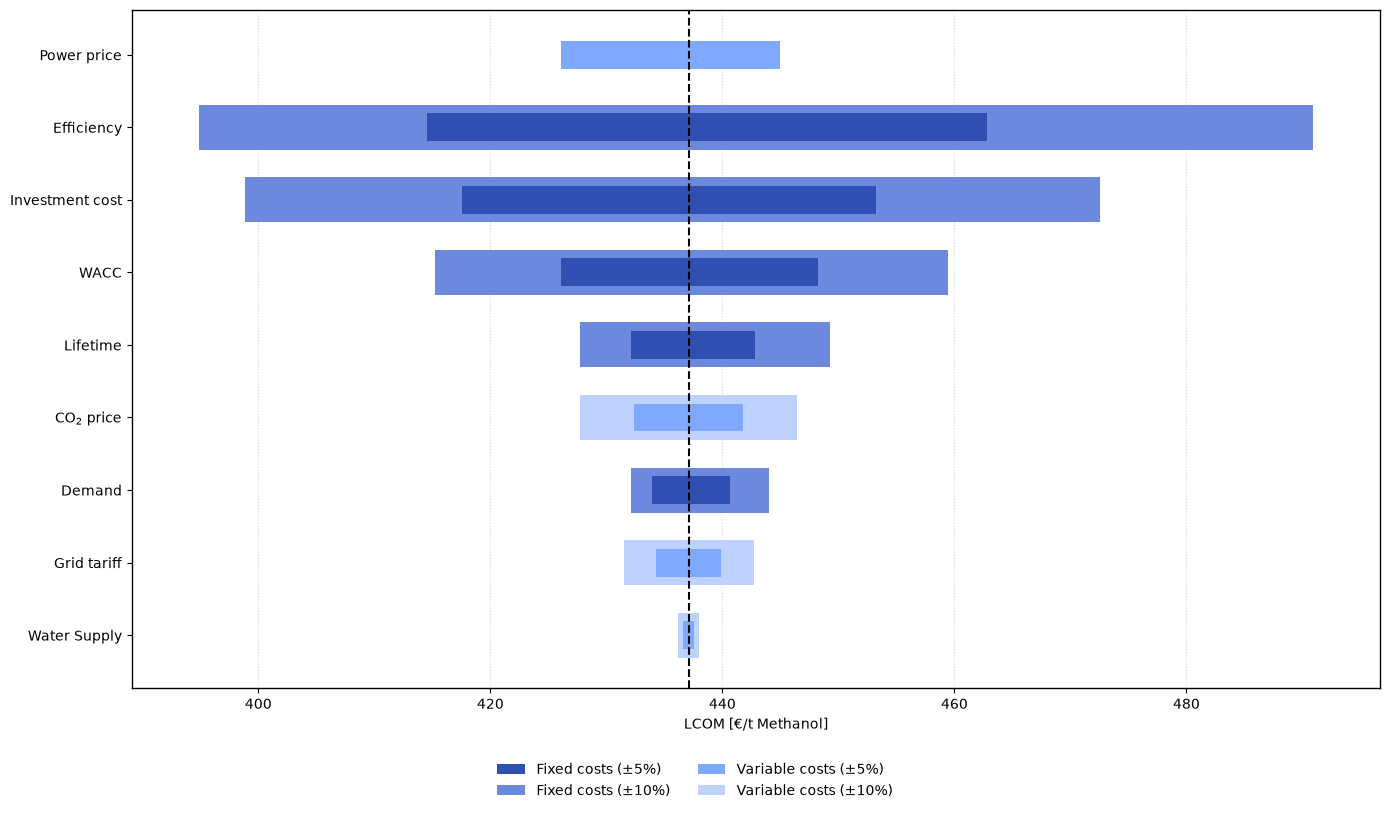

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# -----------------------
# Base value
# -----------------------
base = 437.09

# -----------------------
# Sensitivity data
# (value at -5%, value at +5%)
# -----------------------
sens_5 = {
    "Demand": (433.89, 440.66),
    "WACC": (426.11, 448.22),
    "Lifetime": (442.78, 432.10),
    "Investment cost": (417.56, 453.23),
    "CO$_2$ price": (432.41, 441.77),
    "Power price": (426.08, 445.00),
    "Efficiency": (462.83, 414.52),
    "Grid tariff": (434.29, 439.89),
    "Water Supply":(436.64, 437.54),
}

# -----------------------
# Sensitivity data
# (value at -10%, value at +10%)
# -----------------------
sens_10 = {
    "Demand": (432.12, 444.00),
    "WACC": (415.27, 459.48),
    "Lifetime": (449.27, 427.69),
    "Investment cost": (398.89, 472.59),
    "CO$_2$ price": (427.73, 446.45),
    "Power price": (418.38, 1296.82),
    "Efficiency": (490.92, 394.85),
    "Grid tariff": (431.50, 442.69),
    "Water Supply":(436.19, 437.99),
}

# -----------------------
# Cost type groups
# -----------------------
fixed_costs = {
    "WACC",
    "Lifetime",
    "Investment cost",
    "Demand",
    "Efficiency",
}

variable_costs = {
    "CO$_2$ price",
    "Power price",
    "Grid tariff",
}

# -----------------------
# Colors
# -----------------------
fixed_dark = "#2f4fb3"
fixed_light = "#6d89de"
variable_dark = "#7ea9ff"
variable_light = "#bdd2ff"
color_base = "black"

# -----------------------
# Plot control
# -----------------------
hide_power_price_10 = True  # second version: hide the 10% power price sensitivity

# -----------------------
# Common x-limits
# Exclude the hidden 10% power price outlier so the rest becomes readable
# -----------------------
all_values = [base]
for dname, d in (("5", sens_5), ("10", sens_10)):
    for param, (minus, plus) in d.items():
        if hide_power_price_10 and dname == "10" and param == "Power price":
            continue
        all_values.extend([minus, plus])

x_min = min(all_values)
x_max = max(all_values)
pad = (x_max - x_min) * 0.06
common_xlim = (x_min - pad, x_max + pad)

# -----------------------
# Build ordering
# Keep "Power price" on top, then sort the rest by their span
# -----------------------
items = []
for param in sens_10.keys():
    if param == "Power price":
        continue

    minus5, plus5 = sens_5[param]
    minus10, plus10 = sens_10[param]

    left5, right5 = min(minus5, plus5), max(minus5, plus5)
    left10, right10 = min(minus10, plus10), max(minus10, plus10)

    span = max(right5 - left5, right10 - left10)
    family = "fixed" if param in fixed_costs else "variable"

    items.append((param, left5, right5, left10, right10, span, family))

items.sort(key=lambda x: x[5], reverse=True)

# Insert Power price at the top
pp5_left, pp5_right = min(sens_5["Power price"]), max(sens_5["Power price"])
pp10_left, pp10_right = min(sens_10["Power price"]), max(sens_10["Power price"])

ordered_items = [
    ("Power price", pp5_left, pp5_right, pp10_left, pp10_right, "variable")
] + [(p, l5, r5, l10, r10, fam) for (p, l5, r5, l10, r10, _, fam) in items]

labels = [x[0] for x in ordered_items]
y = np.arange(len(labels))

# -----------------------
# Figure
# -----------------------
fig, ax = plt.subplots(figsize=(14, 8))
bar_h = 0.62

for idx, (_, left5, right5, left10, right10, family) in enumerate(ordered_items):
    if family == "fixed":
        light = fixed_light
        dark = fixed_dark
    else:
        light = variable_light
        dark = variable_dark

    # 10% range (outer, lighter) - omitted for Power price in this version
    if not (hide_power_price_10 and idx == 0):
        ax.barh(
            y[idx],
            right10 - left10,
            left=left10,
            height=bar_h,
            color=light,
            edgecolor="none",
            zorder=2
        )

    # 5% range (inner, darker)
    ax.barh(
        y[idx],
        right5 - left5,
        left=left5,
        height=bar_h * 0.62,
        color=dark,
        edgecolor="none",
        zorder=3
    )

# Base line
ax.axvline(base, color=color_base, linestyle="--", linewidth=1.5, zorder=4)

# Axes
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("LCOM [€/t Methanol]")
ax.set_xlim(common_xlim)
ax.grid(axis="x", linestyle=":", alpha=0.5)

# -----------------------
# Legend
# -----------------------
legend_handles = [
    Patch(facecolor=fixed_dark, edgecolor="none", label="Fixed costs (±5%)"),
    Patch(facecolor=fixed_light, edgecolor="none", label="Fixed costs (±10%)"),
    Patch(facecolor=variable_dark, edgecolor="none", label="Variable costs (±5%)"),
    Patch(facecolor=variable_light, edgecolor="none", label="Variable costs (±10%)"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

# -----------------------
# Spines
# -----------------------
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout(rect=[0, 0.06, 1, 1])

plt.savefig(
    "tornado_plot_methanol_no_powerprice10.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

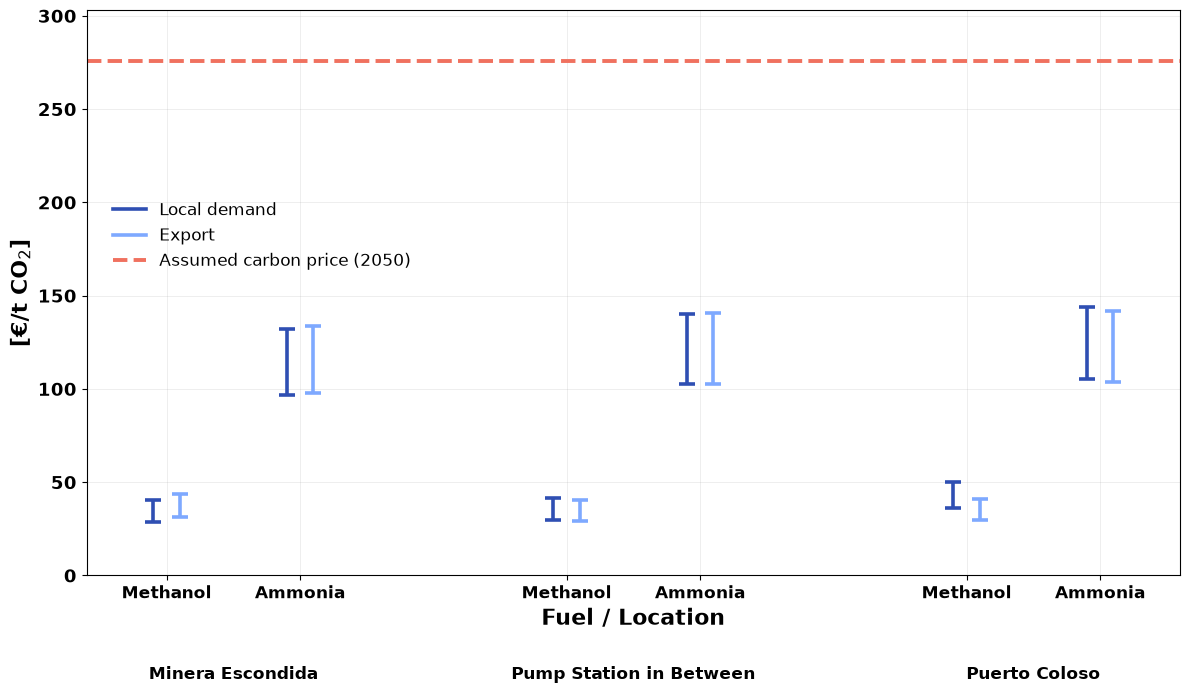

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

# ---------------------------
# X-axis structure
# ---------------------------
locations = ["Minera Escondida", "Pump Station in Between", "Puerto Coloso"]
fuels = ["Methanol", "Ammonia"]

# positions for the six category labels:
# [ME Methanol, ME Ammonia, Pump Methanol, Pump Ammonia, PC Methanol, PC Ammonia]
x = np.array([0, 1, 3, 4, 6, 7], dtype=float)
offset = 0.10
cap_width = 0.06
lw = 2.6

# ---------------------------
# Data
# Carbon price low / high [EUR/tCO2]
# Order must match x above
# ---------------------------
# Methanol
methanol_local_low  = np.array([28.88180619, 29.87571312, 35.9729499])
methanol_local_high = np.array([40.33590786, 41.72398374, 50.23929539])

methanol_export_low  = np.array([31.4621415, 29.01560135, 29.49344122])
methanol_export_high = np.array([43.9395664, 40.52276423, 41.1901084])

# Ammonia
ammonia_local_low  = np.array([96.57820513, 102.5596154, 105.0634615])
ammonia_local_high = np.array([132.1596491, 140.3447368, 143.7710526])

ammonia_export_low  = np.array([97.90961538, 102.8775641, 103.6923077])
ammonia_export_high = np.array([133.9815789, 140.7798246, 141.8947368])

# Flatten in the same order as x
series1_low = np.array([
    methanol_local_low[0],
    ammonia_local_low[0],
    methanol_local_low[1],
    ammonia_local_low[1],
    methanol_local_low[2],
    ammonia_local_low[2],
])

series1_high = np.array([
    methanol_local_high[0],
    ammonia_local_high[0],
    methanol_local_high[1],
    ammonia_local_high[1],
    methanol_local_high[2],
    ammonia_local_high[2],
])

series2_low = np.array([
    methanol_export_low[0],
    ammonia_export_low[0],
    methanol_export_low[1],
    ammonia_export_low[1],
    methanol_export_low[2],
    ammonia_export_low[2],
])

series2_high = np.array([
    methanol_export_high[0],
    ammonia_export_high[0],
    methanol_export_high[1],
    ammonia_export_high[1],
    methanol_export_high[2],
    ammonia_export_high[2],
])

# Ensure correct lower/upper ordering
s1_lo = np.minimum(series1_low, series1_high)
s1_hi = np.maximum(series1_low, series1_high)

s2_lo = np.minimum(series2_low, series2_high)
s2_hi = np.maximum(series2_low, series2_high)

# ---------------------------
# Assumed carbon price
# ---------------------------
exchange_rate = 0.1338
assumed_cp = 2061 * exchange_rate  # EUR/tCO2

# ---------------------------
# Colors
# ---------------------------
color_local_demand = "#2f4fb3"   # dark blue
color_export = "#7ea9ff"         # light blue
color_assumed = "#f0715f"        # dashed red/orange

# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(figsize=(12, 7))

for i in range(len(x)):
    # Local demand
    xpos = x[i] - offset
    ax.vlines(xpos, s1_lo[i], s1_hi[i], colors=color_local_demand, linewidth=lw)
    ax.hlines([s1_lo[i], s1_hi[i]],
              xpos - cap_width, xpos + cap_width,
              colors=color_local_demand, linewidth=lw)

    # Export
    xpos = x[i] + offset
    ax.vlines(xpos, s2_lo[i], s2_hi[i], colors=color_export, linewidth=lw)
    ax.hlines([s2_lo[i], s2_hi[i]],
              xpos - cap_width, xpos + cap_width,
              colors=color_export, linewidth=lw)

# Assumed carbon price line
ax.axhline(
    assumed_cp,
    color=color_assumed,
    linestyle="--",
    linewidth=2.8
)

# ---------------------------
# Axis formatting
# ---------------------------
ax.set_xticks(x)
ax.set_xticklabels(
    ["Methanol", "Ammonia", "Methanol", "Ammonia", "Methanol", "Ammonia"],
    fontsize=12,
    fontweight="bold"
)

# Group labels below the tick labels
group_centers = [0.5, 3.5, 6.5]
for xc, loc in zip(group_centers, locations):
    ax.text(
        xc, -0.16, loc,
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=12,
        fontweight="bold"
    )

ax.set_ylabel("[€/t CO$_2$]", fontsize=16, fontweight="bold")
ax.set_xlabel("Fuel / Location", fontsize=16, fontweight="bold")

ymax = max(s1_hi.max(), s2_hi.max(), assumed_cp) * 1.10
ax.set_ylim(0, ymax)
ax.set_xlim(-0.6, 7.6)

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
for label in ax.get_yticklabels():
    label.set_fontsize(13)
    label.set_fontweight("bold")

ax.grid(True, which="both", linestyle="-", linewidth=0.5, alpha=0.3)

# ---------------------------
# Legend
# ---------------------------
legend_handles = [
    Line2D([0], [0], color=color_local_demand, lw=lw, label="Local demand"),
    Line2D([0], [0], color=color_export, lw=lw, label="Export"),
    Line2D([0], [0], color=color_assumed, lw=2.8, linestyle="--",
           label="Assumed carbon price (2050)")
]

ax.legend(
    handles=legend_handles,
    loc="center left",
    fontsize=12,
    bbox_to_anchor=(0.01, 0.60),
    frameon=False
)

# ---------------------------
# Save
# ---------------------------
plt.tight_layout()
plt.savefig(
    "fig-carbonprices_methanol_ammonia_locations.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

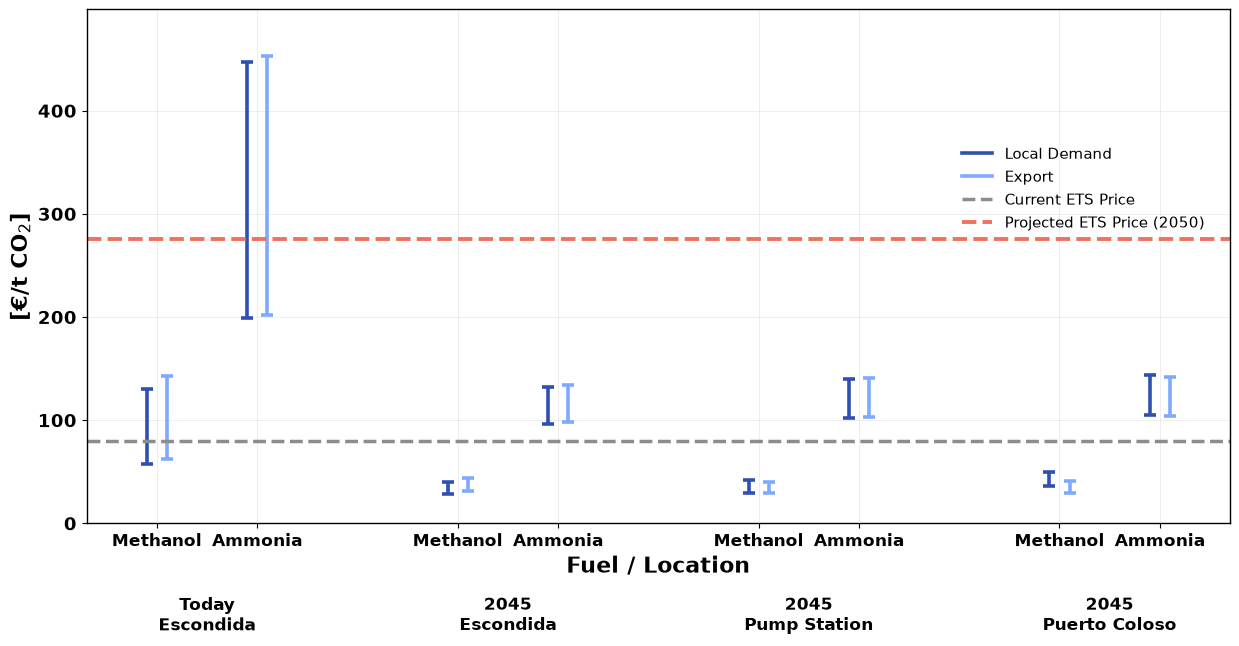

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

# ---------------------------
# X-axis structure
# ---------------------------
x = np.array([0, 1, 3, 4, 6, 7, 9, 10], dtype=float)

tick_labels = [
    "Methanol", "Ammonia",
    "Methanol", "Ammonia",
    "Methanol", "Ammonia",
    "Methanol", "Ammonia"
]

group_centers = [0.5, 3.5, 6.5, 9.5]
group_labels = [
    "Today\nEscondida",
    "2045\nEscondida",
    "2045\nPump Station",
    "2045\nPuerto Coloso"
]

offset = 0.10
cap_width = 0.06
lw = 2.6

# ---------------------------
# Data
# Carbon price low/high [EUR/tCO2]
# Order must match x above:
# Today Escondida (Methanol, Ammonia)
# 2045 Escondida (Methanol, Ammonia)
# 2045 Pump Station (Methanol, Ammonia)
# 2045 Puerto Coloso (Methanol, Ammonia)
# ---------------------------

# Series 1 = Local demand (dark blue)
series1_low = np.array([
    57.20, 199,
    28.88180619, 96.57820513,
    29.87571312, 102.5596154,
    35.9729499, 105.0634615
])

series1_high = np.array([
    130.69, 446.94,
    40.33590786, 132.1596491,
    41.72398374, 140.3447368,
    50.23929539, 143.7710526
])

# Series 2 = Export (light blue)
series2_low = np.array([
    62.31, 201.74,
    31.4621415, 97.90961538,
    29.01560135, 102.8775641,
    29.49344122, 103.6923077
])

series2_high = np.array([
    142.37, 453.10,
    43.9395664, 133.9815789,
    40.52276423, 140.7798246,
    41.1901084, 141.8947368
])

# Ensure correct lower/upper ordering
s1_lo = np.minimum(series1_low, series1_high)
s1_hi = np.maximum(series1_low, series1_high)

s2_lo = np.minimum(series2_low, series2_high)
s2_hi = np.maximum(series2_low, series2_high)

# ---------------------------
# Assumed carbon prices
# ---------------------------
current_cp = 80.0
exchange_rate = 0.1338
projected_cp = 2061 * exchange_rate  # 2045 value

# ---------------------------
# Colors
# ---------------------------
color_local_demand = "#2f4fb3"   # dark blue
color_export = "#7ea9ff"         # light blue
color_current_cp = "#8c8c8c"     # grey dashed
color_projected_cp = "#f0715f"   # reddish dashed

# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(figsize=(12.5, 7.2))

for i in range(len(x)):
    # Local demand
    xpos = x[i] - offset
    ax.vlines(xpos, s1_lo[i], s1_hi[i], colors=color_local_demand, linewidth=lw)
    ax.hlines([s1_lo[i], s1_hi[i]],
              xpos - cap_width, xpos + cap_width,
              colors=color_local_demand, linewidth=lw)

    # Export
    xpos = x[i] + offset
    ax.vlines(xpos, s2_lo[i], s2_hi[i], colors=color_export, linewidth=lw)
    ax.hlines([s2_lo[i], s2_hi[i]],
              xpos - cap_width, xpos + cap_width,
              colors=color_export, linewidth=lw)

# Assumed carbon price lines
ax.axhline(current_cp, color=color_current_cp, linestyle="--", linewidth=2.5)
ax.axhline(projected_cp, color=color_projected_cp, linestyle="--", linewidth=2.8)

# ---------------------------
# Axis formatting
# ---------------------------
ax.set_xticks(x)
ax.set_xticklabels(tick_labels, fontsize=12, fontweight="bold")

for xc, label in zip(group_centers, group_labels):
    ax.text(
        xc, -0.14, label,
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=12,
        fontweight="bold"
    )

ax.set_ylabel("[€/t CO$_2$]", fontsize=16, fontweight="bold")
ax.set_xlabel("Fuel / Location", fontsize=16, fontweight="bold")

ymax = max(s1_hi.max(), s2_hi.max(), current_cp, projected_cp) * 1.10
ax.set_ylim(0, ymax)
ax.set_xlim(-0.7, 10.7)

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
for label in ax.get_yticklabels():
    label.set_fontsize(13)
    label.set_fontweight("bold")

ax.grid(True, which="both", linestyle="-", linewidth=0.5, alpha=0.3)

# ---------------------------
# Legend
# ---------------------------
legend_handles = [
    Line2D([0], [0], color=color_local_demand, lw=lw, label="Local Demand"),
    Line2D([0], [0], color=color_export, lw=lw, label="Export"),
    Line2D([0], [0], color=color_current_cp, lw=2.5, linestyle="--",
           label="Current ETS Price"),
    Line2D([0], [0], color=color_projected_cp, lw=2.8, linestyle="--",
           label="Projected ETS Price (2050)")
]

ax.legend(
    handles=legend_handles,
    loc="center right",
    bbox_to_anchor=(0.99, 0.65),
    fontsize=11,
    frameon=False
)

# ---------------------------
# Final touches
# ---------------------------
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    "fig-carbonprices_methanol_ammonia_today_2045.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

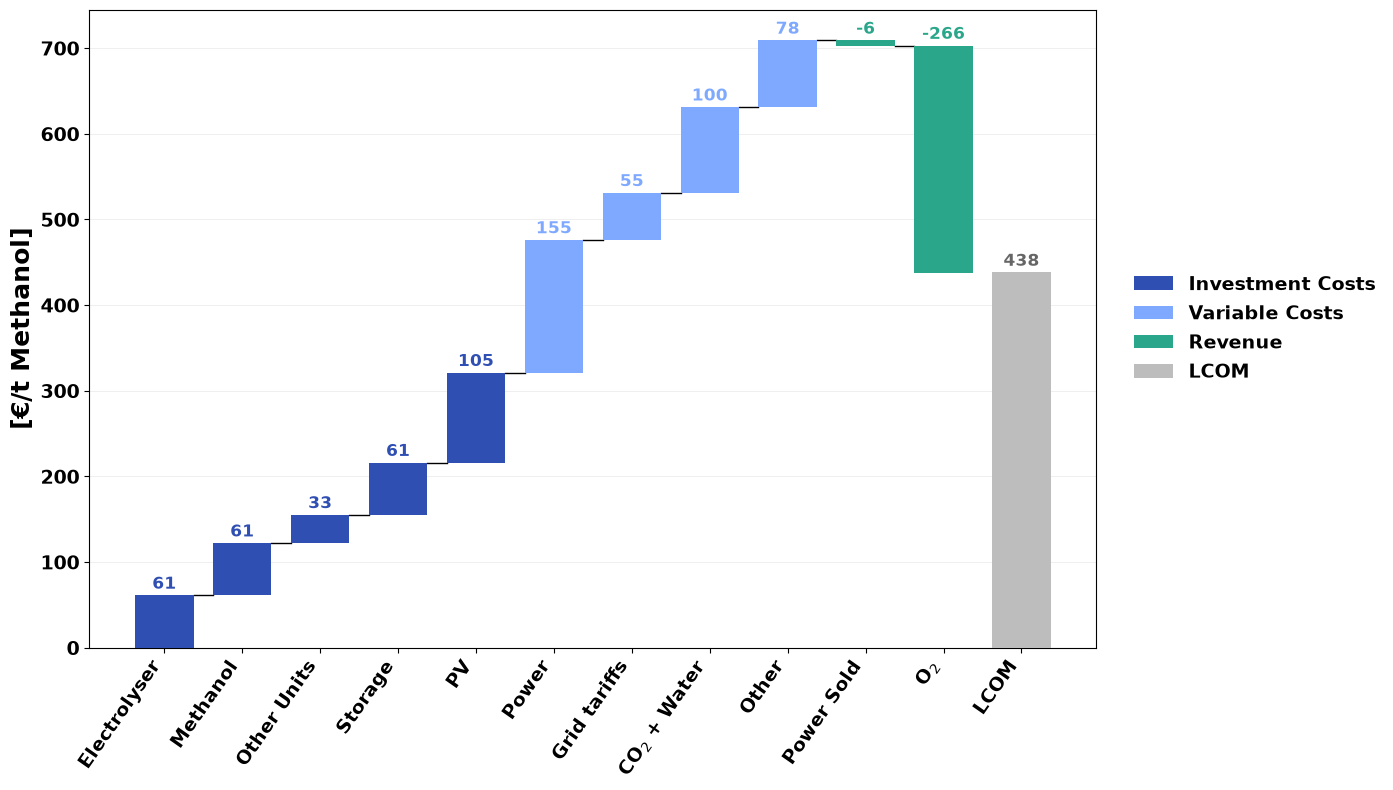

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# -----------------------
# Final Categories
# -----------------------
categories = [
    "Electrolyser",       # investment
    "Methanol",           # investment
    "Other Units",        # investment
    "Storage",            # investment
    "PV",                 # investment
    "Power",              # variable
    "Grid tariffs",       # variable
    "CO$_2$ + Water",     # variable
    "Other",              # variable
    "Power Sold",         # revenue
    "O$_2$",              # revenue
    "LCOM"                # total
]

# -----------------------
# Values
# -----------------------
steps = np.array([
    61,    # Electrolyser
    61,    # Methanol
    33,    # Other Units
    61,    # Storage
    105,   # PV
    155,   # Power
    55,    # Grid tariffs
    100,   # CO2 + Water
    78,    # Other
    -6,    # Power revenue
    -266,  # O2 revenue
    438    # LCOM
], dtype=float)

intermediate = steps[:-1]
total_LCOM = steps[-1]

# cumulative stacking
cum_start = np.concatenate([[0], np.cumsum(intermediate)])[:-1]
cum_end = cum_start + intermediate

# -----------------------
# Colors
# -----------------------
color_invest = "#2f4fb3"     # dark blue
color_variable = "#7ea9ff"   # light blue
color_neg = "#2aa68a"        # green
color_total = "#bdbdbd"      # grey

# Investment / variable split
investment_indices = [0, 1, 2, 3,4]
variable_indices = [5, 6, 7,8]

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(16, 8))
bar_width = 0.75
n_inter = len(intermediate)

for i, (start, end, val) in enumerate(zip(cum_start, cum_end, intermediate)):
    if val >= 0:
        if i in investment_indices:
            color = color_invest
        else:
            color = color_variable
        bottom = start
        height = val
    else:
        color = color_neg
        bottom = end
        height = -val

    ax.bar(i, height, bottom=bottom, width=bar_width,
           color=color, zorder=3)

    # annotation
    y_annot = bottom + height
    txt = f"{int(val):+d}" if val < 0 else f"{int(val)}"
    ax.text(i, y_annot + (max(intermediate) * 0.02),
            txt,
            ha='center', va='bottom',
            fontsize=12, fontweight='bold',
            color=color)

# connectors
for i in range(n_inter - 1):
    x0 = i + bar_width / 2
    x1 = i + 1 - bar_width / 2
    y = cum_end[i]
    ax.plot([x0, x1], [y, y], color='black', lw=1.0)

# final total bar
total_index = n_inter
ax.bar(total_index, total_LCOM, width=bar_width,
       color=color_total, zorder=3)
ax.text(total_index, total_LCOM + (max(intermediate) * 0.02), f"{int(total_LCOM)}",
        ha='center', va='bottom', fontsize=12, fontweight='bold', color='#666666')

# -----------------------
# Axis formatting
# -----------------------
ax.set_xticks(np.arange(len(categories)))
ax.set_xticklabels(categories,
                   rotation=55,
                   ha='right',
                   fontsize=14,
                   fontweight='bold')

ax.set_ylabel('[€/t Methanol]', fontsize=18, fontweight='bold')

for label in ax.get_yticklabels():
    label.set_fontsize(14)
    label.set_fontweight('bold')

ax.yaxis.grid(True, linestyle='-', linewidth=0.5, color='#e9e9e9')
ax.set_axisbelow(True)

# -----------------------
# Legend (outside right)
# -----------------------
legend_handles = [
    Patch(facecolor=color_invest, label='Investment Costs'),
    Patch(facecolor=color_variable, label='Variable Costs'),
    Patch(facecolor=color_neg, label='Revenue'),
    Patch(facecolor=color_total, label='LCOM')
]

leg = ax.legend(handles=legend_handles,
                loc='center left',
                bbox_to_anchor=(1.02, 0.5),
                fontsize=14,
                frameon=False)

for text in leg.get_texts():
    text.set_fontweight('bold')

plt.tight_layout(rect=[0, 0, 0.88, 1])

plt.savefig("waterfall_final.png", dpi=300, bbox_inches='tight')
plt.show()